In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

In [ ]:
kagglehub.login()

In [ ]:
dataset_path = kagglehub.dataset_download(
    "enalis/tomatoes-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'tomatoes-dataset' dataset.
Dataset downloaded to:
/kaggle/input/tomatoes-dataset


In [ ]:
import os

print("Dataset path:")
print(dataset_path)

print("\nFiles and folders:")

for root, dirs, files in os.walk(dataset_path):

    level = root.replace(dataset_path, "").count(os.sep)

    indent = " " * 4 * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:3]:
        print(f"{indent}    {file}")

Dataset path:
/kaggle/input/tomatoes-dataset

Files and folders:
tomatoes-dataset/
    content/
        ieee-mbl-cls/
            val/
                Unripe/
                    u (591).jpg
                    u (464).jpg
                    u (971).jpg
                Damaged/
                    d (531).jpg
                    d (252).png
                    d (352).jpg
                Old/
                    o (1135).jpg
                    o (1134).jpg
                    o (2090).jpg
                Ripe/
                    r (2).jpg
                    r (2454).jpg
                    r (1402).jpg
            train/
                Unripe/
                    u (1265).jpg
                    u (74).jpg
                    u (190).png
                Damaged/
                    d (179).png
                    d (369).jpg
                    d (39).png
                Old/
                    o (1440).jpg
                    o (114).jpg
                    o (1808).jpg
        

In [ ]:
import os

DATASET_PATH = dataset_path

TRAIN_DIR = os.path.join(
    DATASET_PATH,
    "content",
    "ieee-mbl-cls",
    "train"
)

VAL_DIR = os.path.join(
    DATASET_PATH,
    "content",
    "ieee-mbl-cls",
    "val"
)

print("Training Directory:")
print(TRAIN_DIR)

print("\nValidation Directory:")
print(VAL_DIR)

print("\nTraining Classes:")
print(os.listdir(TRAIN_DIR))

print("\nValidation Classes:")
print(os.listdir(VAL_DIR))

Training Directory:
/kaggle/input/tomatoes-dataset/content/ieee-mbl-cls/train

Validation Directory:
/kaggle/input/tomatoes-dataset/content/ieee-mbl-cls/val

Training Classes:
['Unripe', 'Damaged', 'Old', 'Ripe']

Validation Classes:
['Unripe', 'Damaged', 'Old', 'Ripe']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.utils import (
    load_img,
    img_to_array
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
IMG_HEIGHT = 96
IMG_WIDTH = 96

IMAGE_SIZE = (
    IMG_HEIGHT,
    IMG_WIDTH
)

BATCH_SIZE = 32

EPOCHS = 10

print("Image Size:", IMAGE_SIZE)
print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Image Size: (96, 96)
Batch Size: 32
Epochs: 10


In [ ]:
classes = sorted(os.listdir(TRAIN_DIR))

print("Training Images:\n")

total_train = 0

for class_name in classes:

    class_path = os.path.join(
        TRAIN_DIR,
        class_name
    )

    image_count = len([
        file
        for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    total_train += image_count

    print(
        class_name,
        ":",
        image_count
    )


print("\nTotal Training Images:", total_train)


print("\nValidation Images:\n")

total_val = 0

for class_name in classes:

    class_path = os.path.join(
        VAL_DIR,
        class_name
    )

    image_count = len([
        file
        for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])

    total_val += image_count

    print(
        class_name,
        ":",
        image_count
    )


print("\nTotal Validation Images:", total_val)

Training Images:

Damaged : 949
Old : 1992
Ripe : 1975
Unripe : 1584

Total Training Images: 6500

Validation Images:

Damaged : 106
Old : 222
Ripe : 220
Unripe : 176

Total Validation Images: 724


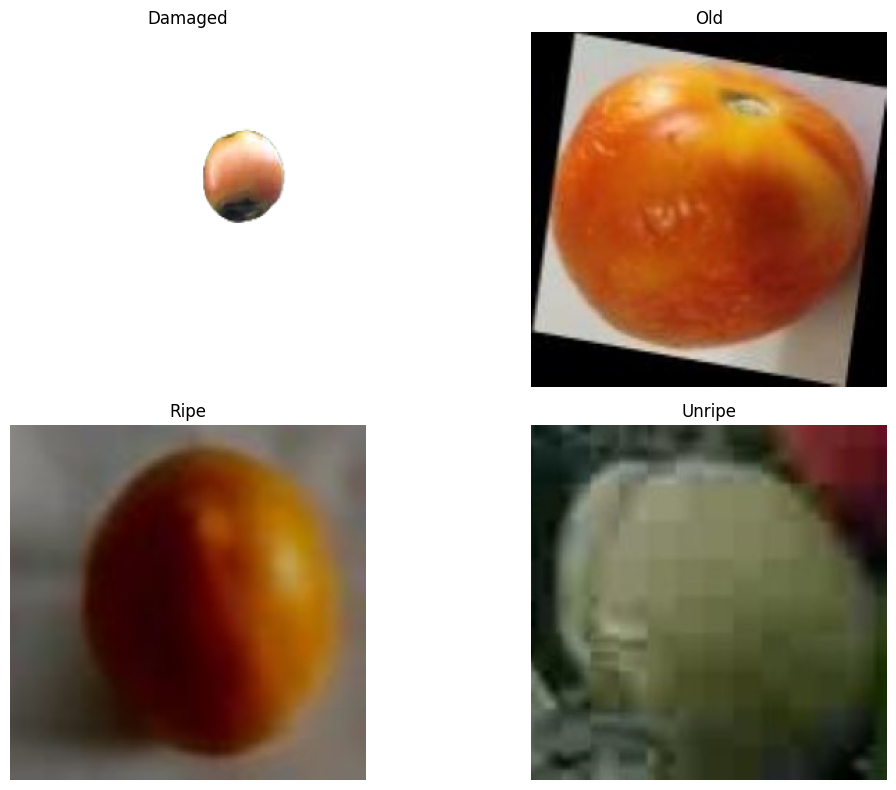

In [ ]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(
        TRAIN_DIR,
        class_name
    )

    image_files = [
        file
        for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    image_path = os.path.join(
        class_path,
        image_files[0]
    )

    image = load_img(image_path)

    plt.subplot(2, 2, i + 1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")


plt.tight_layout()

plt.show()

In [ ]:
train_datagen = ImageDataGenerator(

    rescale=1.0 / 255.0,

    rotation_range=20,

    width_shift_range=0.10,

    height_shift_range=0.10,

    zoom_range=0.15,

    horizontal_flip=True,

    fill_mode="nearest"
)


val_datagen = ImageDataGenerator(

    rescale=1.0 / 255.0
)

In [ ]:
train_data = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=True,

    seed=42
)

Found 6500 images belonging to 4 classes.


In [ ]:
validation_data = val_datagen.flow_from_directory(

    VAL_DIR,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False
)

Found 724 images belonging to 4 classes.


In [ ]:
class_names = list(
    train_data.class_indices.keys()
)

NUM_CLASSES = len(class_names)

print("Number of Classes:", NUM_CLASSES)

print("\nClass Mapping:")

for class_name, index in train_data.class_indices.items():

    print(
        index,
        ":",
        class_name
    )

Number of Classes: 4

Class Mapping:
0 : Damaged
1 : Old
2 : Ripe
3 : Unripe


In [ ]:
images, labels = next(train_data)

print("Image Batch Shape:")

print(images.shape)

print("\nLabel Batch Shape:")

print(labels.shape)

print("\nMinimum Pixel Value:")

print(images.min())

print("\nMaximum Pixel Value:")

print(images.max())

Image Batch Shape:
(32, 96, 96, 3)

Label Batch Shape:
(32, 4)

Minimum Pixel Value:
0.0

Maximum Pixel Value:
1.0


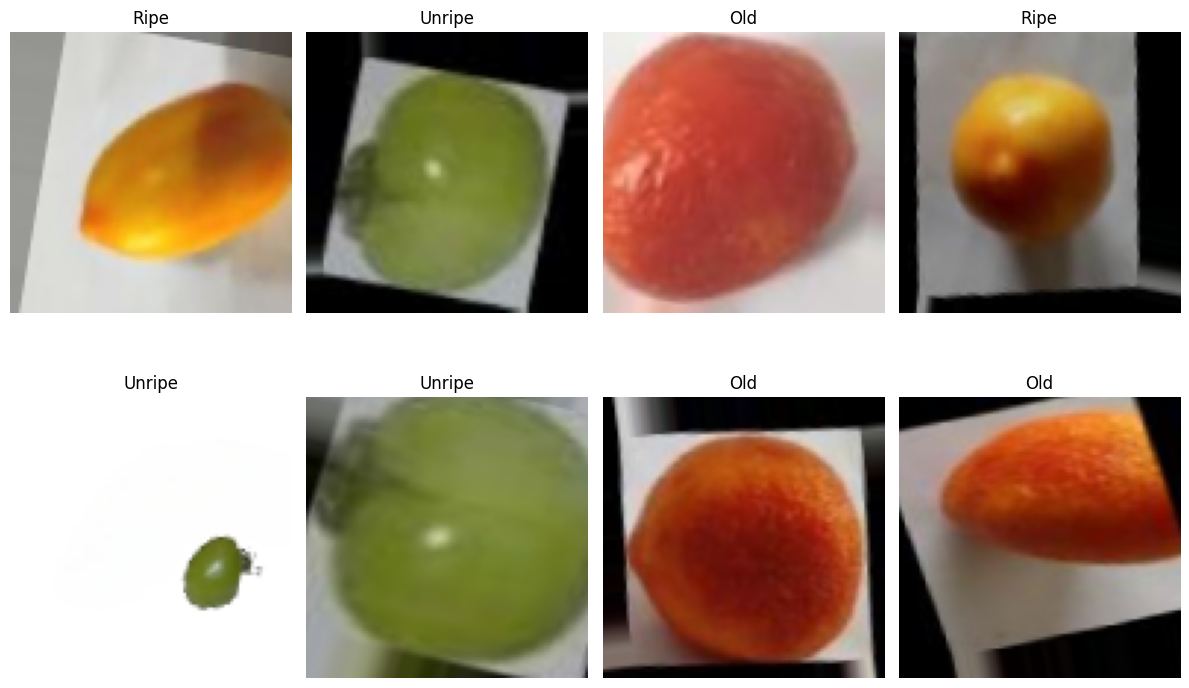

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i])

    label_index = np.argmax(
        labels[i]
    )

    plt.title(
        class_names[label_index]
    )

    plt.axis("off")


plt.tight_layout()

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

model = Sequential([

    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Convolution Block 1
    Conv2D(
        16,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    MaxPooling2D((2, 2)),


    # Convolution Block 2
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    MaxPooling2D((2, 2)),


    # Convolution Block 3
    Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    MaxPooling2D((2, 2)),


    # Reduce feature maps efficiently
    GlobalAveragePooling2D(),


    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),


    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 96, 96, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,004 (109.39 KB)

 Trainable params: 28,004 (109.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(

    train_data,

    validation_data=validation_data,

    epochs=EPOCHS,

    verbose=1
)

Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 108s 520ms/step - accuracy: 0.5588 - loss: 0.9940 - val_accuracy: 0.7348 - val_loss: 0.6840
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 83s 406ms/step - accuracy: 0.7391 - loss: 0.6436 - val_accuracy: 0.7196 - val_loss: 0.6646
Epoch 3/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 85s 419ms/step - accuracy: 0.7643 - loss: 0.5844 - val_accuracy: 0.7942 - val_loss: 0.5290
Epoch 4/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 88s 433ms/step - accuracy: 0.7982 - loss: 0.5119 - val_accuracy: 0.8122 - val_loss: 0.4919
Epoch 5/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 148s 460ms/step - accuracy: 0.8037 - loss: 0.4898 - val_accuracy: 0.8315 - val_loss: 0.4367
Epoch 6/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 89s 435ms/step - accuracy: 0.8188 - loss: 0.4637 - val_accuracy: 0.8191 - val_loss: 0.4586
Epoch 7/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 91s 445ms/step - accuracy: 0.8311 - loss: 0.4199 - val_accuracy: 0.8467 - val_loss: 0.4000
Epoch 8/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 84s 412ms/step - accuracy: 0.8251 - loss:

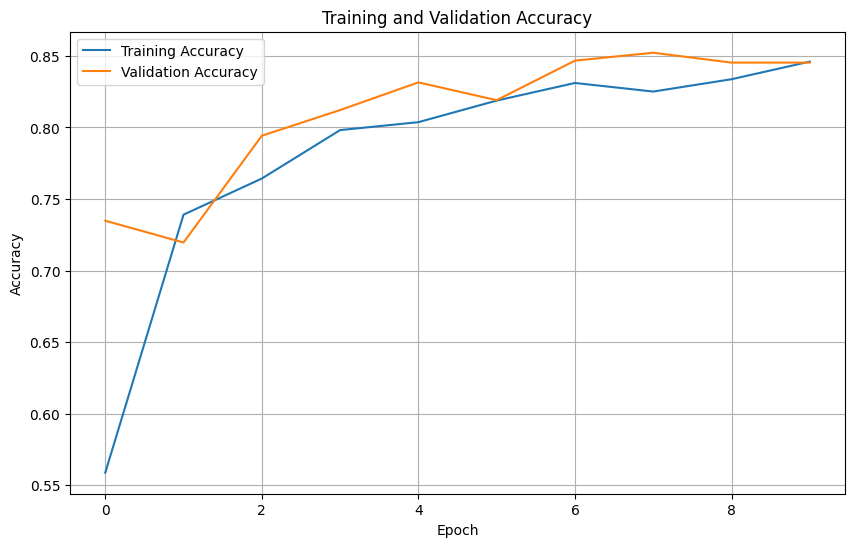

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

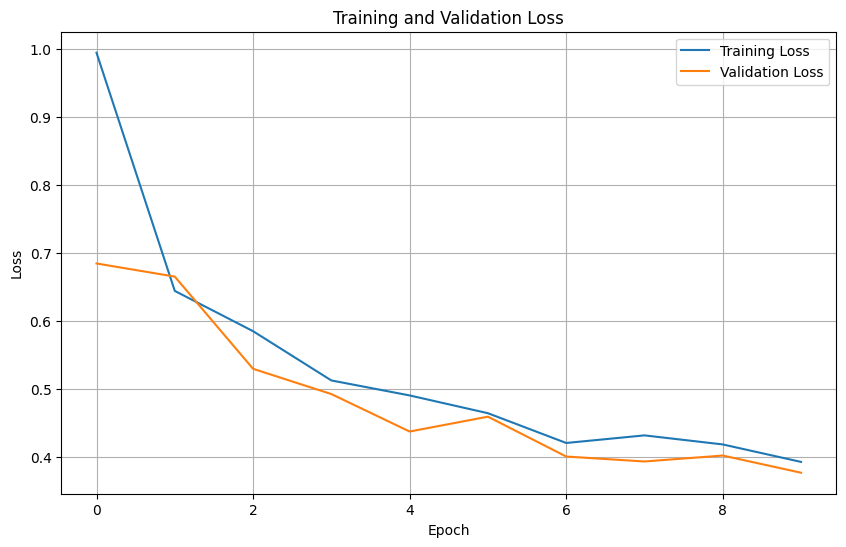

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
validation_loss, validation_accuracy = model.evaluate(

    validation_data,

    verbose=1
)

print(
    "Validation Loss:",
    validation_loss
)

print(
    "Validation Accuracy:",
    validation_accuracy
)

print(
    "Validation Accuracy Percentage:",
    validation_accuracy * 100,
    "%"
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.8453 - loss: 0.3761
Validation Loss: 0.3761461079120636
Validation Accuracy: 0.8453038930892944
Validation Accuracy Percentage: 84.53038930892944 %


In [ ]:
validation_data.reset()

predictions = model.predict(
    validation_data,
    verbose=1
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = validation_data.classes

print(
    "Total Predictions:",
    len(predicted_classes)
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step
Total Predictions: 724


In [ ]:
print(
    classification_report(

        true_classes,

        predicted_classes,

        target_names=class_names,

        digits=4,

        zero_division=0
    )
)

              precision    recall  f1-score   support

     Damaged     0.6146    0.5566    0.5842       106
         Old     0.7830    0.8288    0.8053       222
        Ripe     0.9349    0.9136    0.9241       220
      Unripe     0.9438    0.9545    0.9492       176

    accuracy                         0.8453       724
   macro avg     0.8191    0.8134    0.8157       724
weighted avg     0.8436    0.8453    0.8440       724



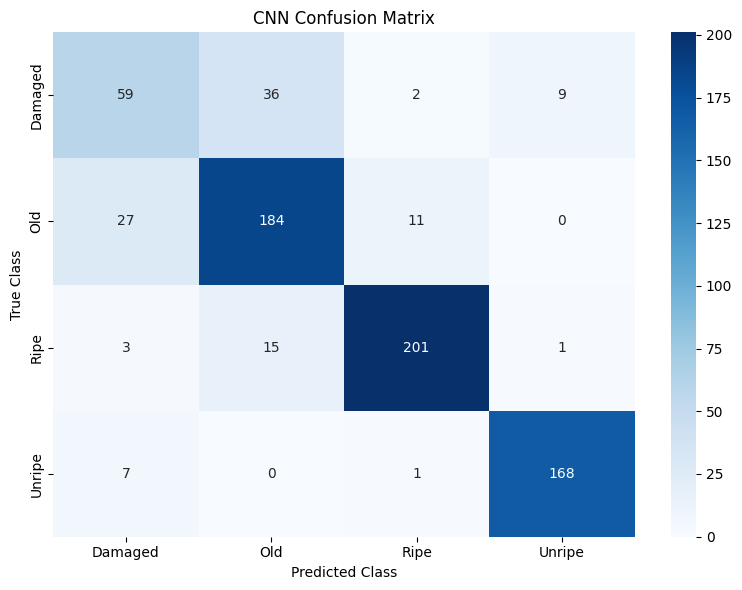

In [ ]:
cm = confusion_matrix(

    true_classes,

    predicted_classes
)

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.title(
    "CNN Confusion Matrix"
)

plt.tight_layout()

plt.show()

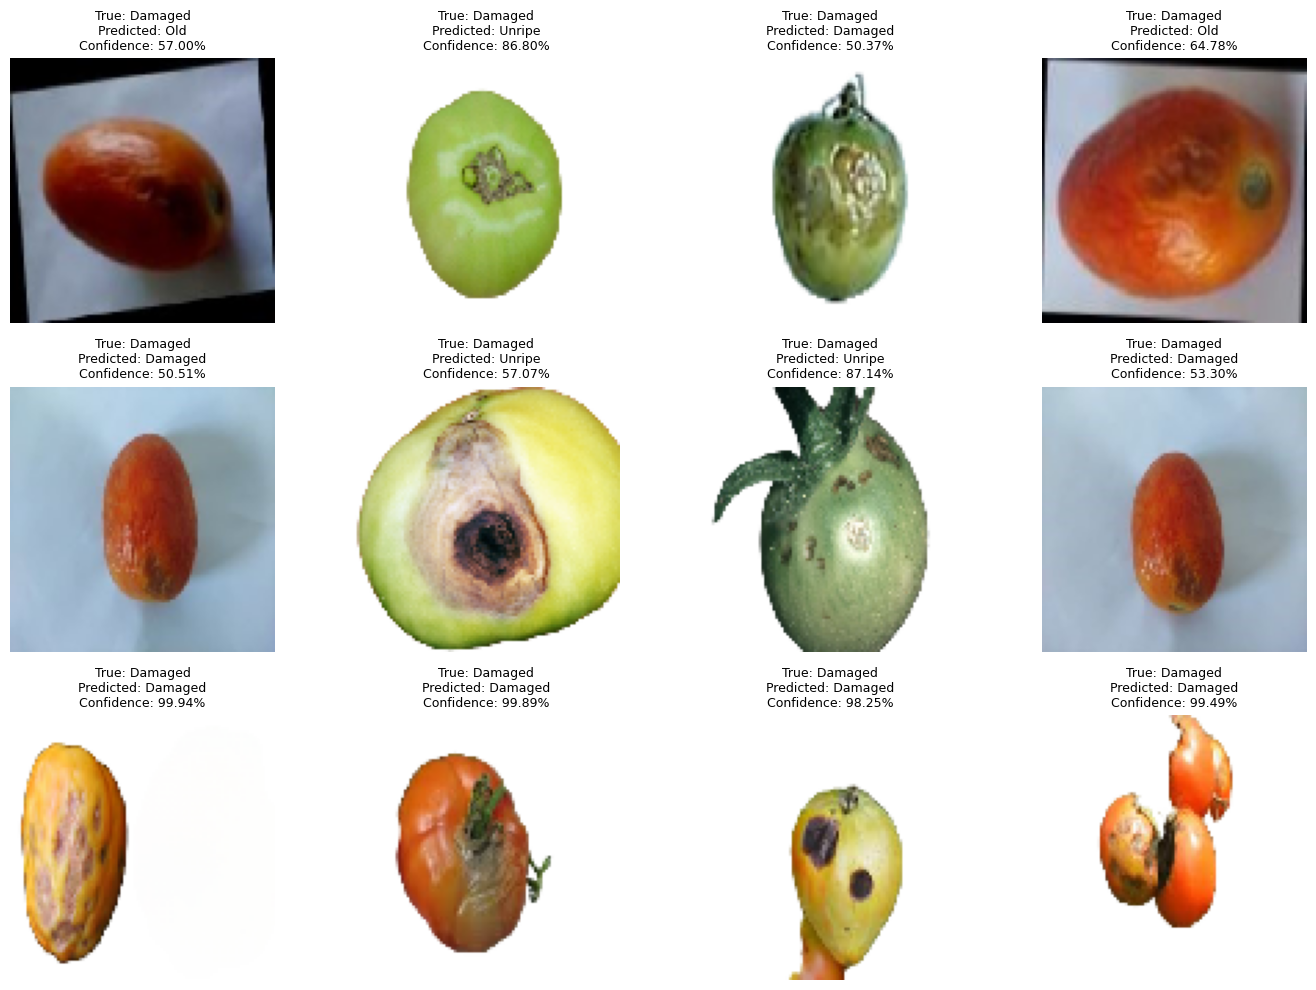

In [ ]:
validation_data.reset()

sample_images, sample_labels = next(
    validation_data
)

sample_predictions = model.predict(
    sample_images,
    verbose=0
)

plt.figure(
    figsize=(14, 10)
)

for i in range(
    min(12, len(sample_images))
):

    true_index = np.argmax(
        sample_labels[i]
    )

    predicted_index = np.argmax(
        sample_predictions[i]
    )

    confidence = (
        sample_predictions[i][predicted_index]
        * 100
    )

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        sample_images[i]
    )

    plt.title(

        f"True: {class_names[true_index]}\n"

        f"Predicted: {class_names[predicted_index]}\n"

        f"Confidence: {confidence:.2f}%",

        fontsize=9
    )

    plt.axis("off")


plt.tight_layout()

plt.show()

In [ ]:
MODEL_NAME = "tomato_cnn_model.keras"

model.save(
    MODEL_NAME
)

print(
    "Model saved successfully!"
)

print(
    "Model file:",
    MODEL_NAME
)

Model saved successfully!
Model file: tomato_cnn_model.keras
